In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
class NoiseScheduler:
    def __init__(self, T=1000, schedule="linear", beta_start=0.0001, beta_end=0.02):
        self.T = T
        if schedule == "linear":
            self.betas = torch.linspace(beta_start, beta_end, T)
            self.alphas = 1 - self.betas
            self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        elif schedule == "cosine":
            s = 0.008
            t = torch.arange(0, T+1)
            alpha_bars = torch.cos(((t/T + s) / (1 + s)) * torch.pi / 2) ** 2
            alpha_bars = alpha_bars / alpha_bars[0]
            self.betas = (1 - alpha_bars[1:] / alpha_bars[:-1]).clamp(0, 0.999)
            self.alphas = 1 - self.betas
            self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        
    def add_noise(self, x0, t, epsilon):
        # t is an integer or batch of integers
        device = x0.device
        alpha_bar_t = self.alpha_bars.to(t.device)[t]
        
        # reshape for broadcasting with image dimensions (B, C, H, W)
        while alpha_bar_t.dim() < x0.dim():
            alpha_bar_t = alpha_bar_t.unsqueeze(-1)
        
        xt = torch.sqrt(alpha_bar_t) * x0 + torch.sqrt(1 - alpha_bar_t) * epsilon
        return xt

class TimeEmbedding(nn.Module):
    # PE(t, 2i) = sin(t / 10000^(2i/d))
    # PE(t, 2i+1) = cos(t / 10000^(2i/d))
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        self.mlp = nn.Sequential(
            nn.Linear(in_features=dim, out_features=dim*2),
            nn.SiLU(),
            nn.Linear(in_features=dim*2, out_features=dim)
        )
    def forward(self, t):
        # t shape: (batch,)
        device = t.device
        half_dim = self.dim // 2
        i = torch.arange(0, half_dim, device=device) 
        div_term = 10000 ** (2 * i / self.dim)
        
        # t needs to be (batch, 1) to broadcast against div_term (half_dim,)
        t = t.unsqueeze(1).float()
        
        sins = torch.sin(t/div_term)
        coss = torch.cos(t/div_term)
        emb = torch.cat((sins, coss), dim=-1)
        return self.mlp(emb)  # shape: (batch, dim)

In [6]:
def get_groups(channels):
    for g in [32, 16, 8, 4, 2, 1]:
        if channels % g == 0:
            return g
    return 1

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, time_dim, num_groups=2):
        super().__init__()
        # block1: conv → groupnorm → silu
        self.block_1 = nn.Sequential(
            nn.GroupNorm(get_groups(in_channels), in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, 
                                  kernel_size=kernel_size, padding=1),
        )
        # block2: conv → groupnorm → silu
        self.block_2 = nn.Sequential(
            nn.GroupNorm(get_groups(out_channels), out_channels ),
            nn.SiLU(),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, 
                                  kernel_size=kernel_size, padding=1),
        )
        # time_mlp: linear to project time embedding to out_channels
        self.mlp = nn.Linear(time_dim, out_channels)
        # residual_conv: 1x1 conv if in_channels != out_channels, else identity
        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual_conv = nn.Identity()
        
    def forward(self, x, t):
        org_x = x
        # 1. pass x through block1
        x = self.block_1(x)
        # 2. project t embedding and add to output
        mapped_embeddings = self.mlp(t).unsqueeze(-1).unsqueeze(-1)    
        x = x+mapped_embeddings
        # 3. pass through block2
        x = self.block_2(x)
        # 4. add residual connection
        return self.residual_conv(org_x) + x

class SelfAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.norm = nn.GroupNorm(1, channels)
        self.attention = nn.MultiheadAttention(channels, num_heads, batch_first=True)
        
    def forward(self, x):
        B, C, H, W = x.shape
        # normalize
        x_norm = self.norm(x)
        # reshape to sequence: (B, H*W, C)
        x_flat = x_norm.reshape(B, C, H*W).transpose(1, 2)
        # self attention
        attn_out, _ = self.attention(x_flat, x_flat, x_flat)
        # reshape back: (B, C, H, W)
        attn_out = attn_out.transpose(1, 2).reshape(B, C, H, W)
        # residual connection
        return x + attn_out

class Unet(nn.Module):
    def __init__(self, in_channels, out_channel, kernel_size, time_dim, num_groups:int=2):
        super().__init__()
        # Encoder Part ResBlocks
        self.encoder_resblock_1 = ResBlock(in_channels, out_channel, kernel_size, time_dim, num_groups)
        self.encoder_resblock_2 = ResBlock(out_channel, out_channel*2, kernel_size, time_dim, num_groups)
        # Encoder Downsamplers
        self.downsampler1 = nn.MaxPool2d(2)
        self.downsampler2 = nn.MaxPool2d(2)

        # BottleNeck:
        self.bottleneck = ResBlock(out_channel*2, out_channel*2, kernel_size, time_dim, num_groups)
        self.attn_ = SelfAttention(channels=out_channel*2)
        # Decoder Resblocks
        self.decoder_resblock_1 = ResBlock(out_channel*4, out_channel, kernel_size, time_dim, num_groups)
        self.decoder_resblock_2 = ResBlock(out_channel*2, out_channel, kernel_size, time_dim, num_groups)
        # Decoder Upsamplers
        self.upsampler1 = nn.Upsample(scale_factor=2)
        self.upsampler2 = nn.Upsample(scale_factor=2)

        # Embedding layer
        self.embeddings = TimeEmbedding(dim=time_dim)
        # output layer
        self.output_layer = nn.Conv2d(out_channel, in_channels, kernel_size=1)

    def forward(self, x, t):
        # 1. time embedding
        t_emb = self.embeddings(t)
        # 2. encoder block 1 + save skip1
        ex1 = self.encoder_resblock_1(x, t_emb)
        # 3. downsample
        down_ex1 = self.downsampler1(ex1)
        # 4. encoder block 2 + save skip2
        ex2 = self.encoder_resblock_2(down_ex1, t_emb)
        # 5. downsample
        down_ex2 = self.downsampler2(ex2)

        # 6. bottleneck
        btnx = self.bottleneck(down_ex2, t_emb)
        btnx = self.attn_(btnx)

        # 7. upsample
        up_dx1 = self.upsampler1(btnx)
        # 8. concat skip2 + decoder block 1
        cat1 = torch.cat([up_dx1, ex2], dim=1)
        dx1 = self.decoder_resblock_1(cat1, t_emb) 
        # 9. upsample
        up_dx2 = self.upsampler2(dx1)
        # 10. concat skip1 + decoder block 2
        cat2 = torch.cat([up_dx2, ex1], dim=1)
        dx2 = self.decoder_resblock_2(cat2, t_emb)

        # 11. output conv
        out = self.output_layer(dx2)
        return out

In [7]:
def _sample(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas
    alphas = noise_scheduler.alphas
    alpha_bars = noise_scheduler.alpha_bars
    with torch.no_grad():
        xt = torch.randn(n_samples, 1, 28, 28).to(device)   
        for t in range(999, 0, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            x_prev = (1/torch.sqrt(alphas[t])) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t])) * pred_noise) + sigma_t * z
            xt = x_prev
    return xt

def _plot(samples, filename:str):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i, ax in enumerate(axes):
        img = samples[i, 0].cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.savefig(filename, dpi=150)
    plt.show()

In [17]:
def train(model, noise_scheduler, train_dl, val_dl, optimizer,
           epochs, device, lr_scheduler, n_samples:int=8, _sample:callable=_sample, model_name:str="ddpm"):
    print(f"Using: {device}")
    best_val_loss = float('inf')
    
    for epoch in range(epochs):
        # training loop
        model.train()
        train_loss = 0
        for x0, _ in train_dl:
            x0 = x0.to(device)
            t = torch.randint(0, 1000, size=(x0.shape[0],)).to(device)
            true_noise = torch.randn_like(x0)
            noisy_x0 = noise_scheduler.add_noise(x0, t, true_noise)
            pred_noise = model(noisy_x0, t)
            _mse = F.mse_loss(pred_noise, true_noise)
            _mse.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            lr_scheduler.step()
        
            optimizer.zero_grad()
            train_loss += _mse.item()

        
        # validation loop
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x0, _ in val_dl:
                x0 = x0.to(device)
                t = torch.randint(0, 1000, size=(x0.shape[0],)).to(device)
                true_noise = torch.randn_like(x0)
                noisy_x0 = noise_scheduler.add_noise(x0, t, true_noise)
                pred_noise = model(noisy_x0, t)
                _mse = F.mse_loss(pred_noise, true_noise)
                val_loss += _mse.item()

        if epoch % 10 == 0:
            samples = _sample(model, noise_scheduler, n_samples=n_samples, device=device)
            filesname = "../plots/" + model_name + f"samples{epoch}.png"
            _plot(samples, filesname)
        
        # checkpointing
        avg_val = val_loss / len(val_dl)
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), '../models/ddpm_cifar10_best.pth')
            print(f"Saved best model at epoch {epoch}")
        
        print(f"Epoch {epoch} | Train: {train_loss/len(train_dl):.4f} | Val: {avg_val:.4f}")

In [ ]:
batch_size = 64

In [18]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))  # normalize to [-1, 1]
])

dataset = datasets.FashionMNIST(root='../data', train=True, download=True, transform=transform)
dl = DataLoader(dataset, batch_size=32, shuffle=True)

val_dataset = datasets.FashionMNIST(root='../data', train=False, download=True, transform=transform)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
lr = 1e-4
epochs = 50
steps_per_epoch = len(dl) 

Using: cuda


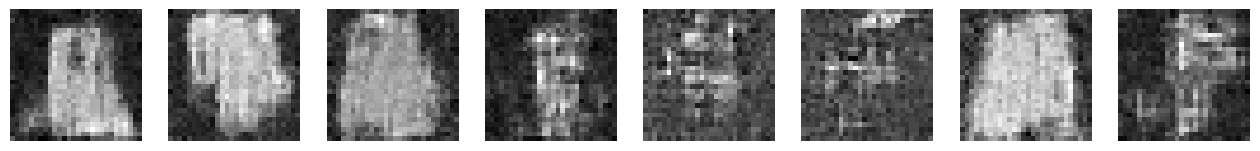

Saved best model at epoch 0
Epoch 0 | Train: 0.1601 | Val: 0.0865
Saved best model at epoch 1
Epoch 1 | Train: 0.0750 | Val: 0.0698
Saved best model at epoch 2
Epoch 2 | Train: 0.0646 | Val: 0.0611
Saved best model at epoch 3
Epoch 3 | Train: 0.0579 | Val: 0.0562
Saved best model at epoch 4
Epoch 4 | Train: 0.0538 | Val: 0.0525
Saved best model at epoch 5
Epoch 5 | Train: 0.0511 | Val: 0.0523
Saved best model at epoch 6
Epoch 6 | Train: 0.0493 | Val: 0.0507
Saved best model at epoch 7
Epoch 7 | Train: 0.0480 | Val: 0.0469
Saved best model at epoch 8
Epoch 8 | Train: 0.0473 | Val: 0.0468
Saved best model at epoch 9
Epoch 9 | Train: 0.0461 | Val: 0.0468


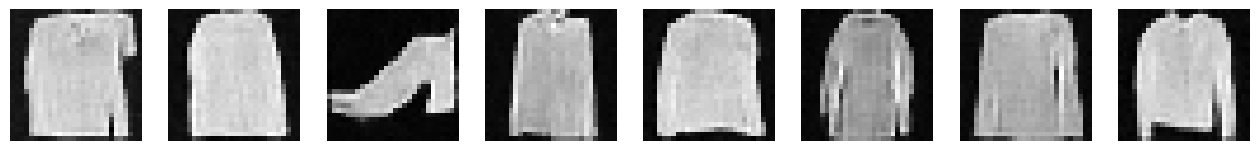

Saved best model at epoch 10
Epoch 10 | Train: 0.0449 | Val: 0.0458


KeyboardInterrupt: 

In [20]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Unet(in_channels=1, out_channel=64, kernel_size=3, time_dim=128).to(device)
noise_scheduler = NoiseScheduler()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, steps_per_epoch=steps_per_epoch, epochs=50)

train(model, noise_scheduler, dl, val_dl, optimizer=optimizer, epochs=50, device=device, lr_scheduler=scheduler,
      _sample=_sample, model_name="ddpm_fashionmnist")

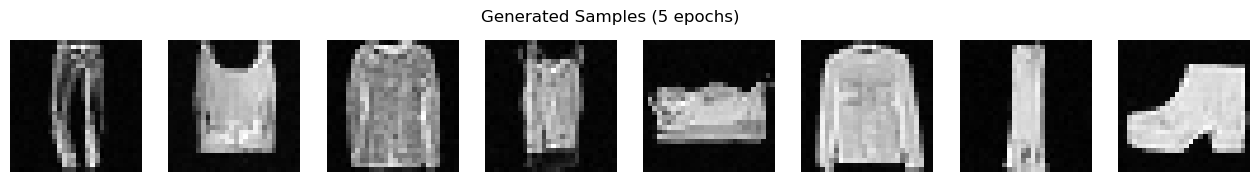

In [ ]:
def _sample(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas
    alphas = noise_scheduler.alphas
    alpha_bars = noise_scheduler.alpha_bars
    with torch.no_grad():
        xt = torch.randn(n_samples, 1, 28, 28).to(device)   
        for t in range(999, 0, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            x_prev = (1/torch.sqrt(alphas[t])) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t])) * pred_noise) + sigma_t * z
            xt = x_prev
    return xt

# visualize
samples = _sample(model, noise_scheduler, n_samples=8, device=device)

def _plot(samples, filename:str):
    fig, axes = plt.subplots(1, 8, figsize=(16, 2))
    for i, ax in enumerate(axes):
        img = samples[i, 0].cpu().numpy()
        ax.imshow(img, cmap='gray')
        ax.axis('off')
    plt.savefig(filename, dpi=150)
    plt.show()

In [25]:
torch.save(model.state_dict(), '../models/ddpm_fashionmnist_50epochs.pth')

#### CIFAR - 10

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

dataset = datasets.CIFAR10(root='../data', train=True, download=True, transform=transform)
dl = DataLoader(dataset, batch_size=32, shuffle=True)

Files already downloaded and verified


In [7]:
val_dataset = datasets.CIFAR10(root='../data', train=False, download=True, transform=transform)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False)

Files already downloaded and verified


In [10]:
lr = 1e-4
epochs = 25
steps_per_epoch = len(dl) 

In [11]:
steps_per_epoch

1563

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Unet(in_channels=3, out_channel=128, kernel_size=3, time_dim=128).to(device)
noise_scheduler = NoiseScheduler()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
print(f"no of model parameters: sum([p.numel() for p in model.parameters()])")
lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=lr, epochs=epochs,
                                                   steps_per_epoch=steps_per_epoch)

train(model, noise_scheduler, dl, val_dl, optimizer, epochs, device, lr_scheduler=lr_scheduler)

Using: cuda
Saved best model at epoch 0
Epoch 0 | Train: 0.1471 | Val: 0.0574
Saved best model at epoch 1
Epoch 1 | Train: 0.0511 | Val: 0.0450
Saved best model at epoch 2
Epoch 2 | Train: 0.0445 | Val: 0.0411
Saved best model at epoch 3
Epoch 3 | Train: 0.0406 | Val: 0.0391
Saved best model at epoch 4
Epoch 4 | Train: 0.0393 | Val: 0.0386
Saved best model at epoch 5
Epoch 5 | Train: 0.0379 | Val: 0.0374
Epoch 6 | Train: 0.0365 | Val: 0.0382
Saved best model at epoch 7
Epoch 7 | Train: 0.0362 | Val: 0.0360
Epoch 8 | Train: 0.0358 | Val: 0.0373
Epoch 9 | Train: 0.0354 | Val: 0.0364
Saved best model at epoch 10
Epoch 10 | Train: 0.0350 | Val: 0.0342
Epoch 11 | Train: 0.0343 | Val: 0.0354
Epoch 12 | Train: 0.0345 | Val: 0.0348
Saved best model at epoch 13
Epoch 13 | Train: 0.0334 | Val: 0.0334
Saved best model at epoch 14
Epoch 14 | Train: 0.0341 | Val: 0.0331
Epoch 15 | Train: 0.0336 | Val: 0.0333
Epoch 16 | Train: 0.0330 | Val: 0.0332
Saved best model at epoch 17
Epoch 17 | Train: 0.032

In [ ]:
noise_scheduler = NoiseScheduler()

In [10]:
device = "cuda"
model = Unet(in_channels=3, out_channel=128, kernel_size=3, time_dim=128).to(device)
model.load_state_dict(torch.load('../models/ddpm_cifar10_best.pth', map_location=device))
model.eval()

C:\Users\praty\AppData\Local\Temp\ipykernel_2976\2436746234.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('../models/ddpm_cifar10_best

Unet(
  (encoder_resblock_1): ResBlock(
    (block_1): Sequential(
      (0): GroupNorm(1, 3, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (block_2): Sequential(
      (0): GroupNorm(32, 128, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (mlp): Linear(in_features=128, out_features=128, bias=True)
    (residual_conv): Conv2d(3, 128, kernel_size=(1, 1), stride=(1, 1))
  )
  (encoder_resblock_2): ResBlock(
    (block_1): Sequential(
      (0): GroupNorm(32, 128, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (block_2): Sequential(
      (0): GroupNorm(32, 256, eps=1e-05, affine=True)
      (1): SiLU()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (mlp): Linear(in_features=128, out_features=256, bia

tensor(-1.0019, device='cuda:0') tensor(0.9013, device='cuda:0') tensor(0.0069, device='cuda:0')


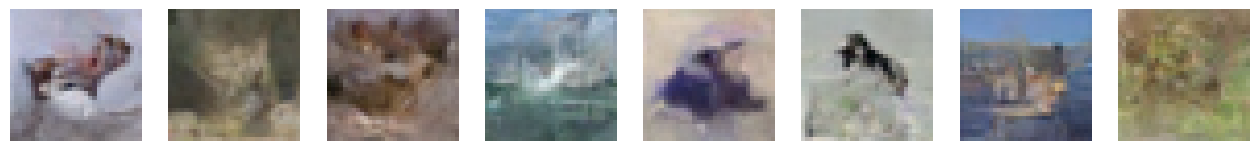

In [16]:
def sample(model, noise_scheduler, n_samples, device):
    model.eval()
    betas = noise_scheduler.betas.to(device)
    alphas = noise_scheduler.alphas.to(device)
    alpha_bars = noise_scheduler.alpha_bars.to(device)
    with torch.no_grad():
        xt = torch.randn(n_samples, 3, 32, 32).to(device)   
        for t in range(999, -1, -1):
            t_batch = torch.tensor([t] * n_samples).to(device)
            pred_noise = model(xt, t_batch)
            pred_nosie = pred_noise.clamp(-1, 1)
            z = torch.randn_like(xt) if t > 0 else torch.zeros_like(xt)
            sigma_t = torch.sqrt(betas[t])
            denom  = torch.sqrt(alphas[t]) + 1e-8
            x_prev = (1/denom) * (xt - (betas[t]/torch.sqrt(1 - alpha_bars[t] + 1e-8)) * pred_noise) + sigma_t * z
            xt = x_prev.clamp(-2, 2)
    return xt

# visualize
samples = sample(model, noise_scheduler, n_samples=8, device=device)
print(samples.min(), samples.max(), samples.mean())
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img = samples[i].cpu().numpy()  # (3, 32, 32)
    img = img.transpose(1, 2, 0)   # (32, 32, 3)
    img = (img + 1) / 2            # denormalize from [-1,1] to [0,1]
    img = img.clip(0, 1)
    ax.imshow(img)
    ax.axis('off')
plt.savefig('samples_cifar.png', dpi=150)
plt.show()

In [14]:
sum([p.numel() for p in model.parameters()])

3978505